<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/gradient-collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms

## Example


In [27]:
# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

T3r3=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 1.,  0., -8.],
       [ 0.,  1., -8.],
       [ 0.,  0.,  1.]], dtype=float32)>
T3r3=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 1.       ,  0.       , -3.1999998],
       [ 0.       ,  1.       , -8.       ],
       [ 0.       ,  0.       ,  1.       ]], dtype=float32)>
T3r3=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 1.       ,  0.       ,  1.6000004],
       [ 0.       ,  1.       , -8.       ],
       [ 0.       ,  0.       ,  1.       ]], dtype=float32)>
T3r3=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 1.       ,  0.       ,  6.4000006],
       [ 0.       ,  1.       , -8.       ],
       [ 0.       ,  0.       ,  1.       ]], dtype=float32)>
T3r3=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 1.      ,  0.      , 11.200001],
       [ 0.      ,  1.      , -8.      ],
       [ 0.      ,  0.      ,  1.      ]], dtype=float32)>
T3r3=<tf.Tensor: shape=(3, 3), dtype=float32, n

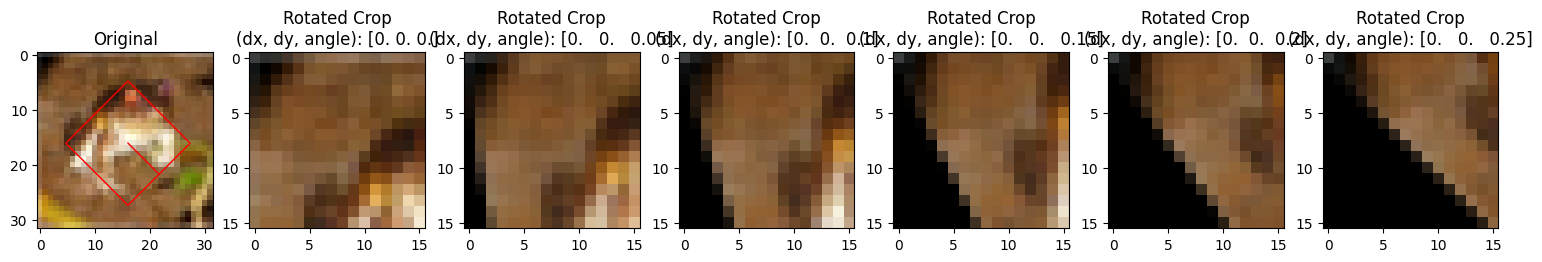

In [151]:
# image manipulation function
def rotated_crop(image, dx, dy, da):
    """
    Takes a 50% crop of the source image after applying a positional and angular
    offset relative to the image's centre.
    For example, (dx,dy,da) = (-0.25,0,0.5) will take a crop centred one quarter
    of the image width to the left from the source image centre and rotated
    45 degrees (50% of 180 in whichever direction the positive direction happens
    to take).
    Args:
      image: source image
      dx: float in range -0.5 .. +0.5 (fraction of width)
      dy: float in range -0.5 .. +0.5 (fraction of height)
      da: float in range -1.0 .. +1.0 (fraction of radians)
    Returns:
      cropped image
    """
    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    img_centre_x = img_width // 2
    img_centre_y = img_height // 2
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)
    crop_centre_x = crop_size // 2
    crop_centre_y = crop_size // 2

    # Compute homography matrix from translation and rotation
    cos_val = tf.cos(da * np.pi)
    sin_val = tf.sin(da * np.pi)

    # Step 1: Translate crop center by (dx * width, dy * height)
    tx1 = dx * img_width
    ty1 = dy * img_height

    # Step 2: Translate to move origin to crop center for rotation
    #tx2 = -img_centre_x - tx1
    #ty2 = -img_centre_y - ty1
    #tx2 = img_centre_x - crop_centre_x  # <--- successfully moves img centre to crop centre
    #ty2 = img_centre_y - crop_centre_y
    #print()
    #print(f"{da=}")
    tx2 = img_centre_x  # <-- successfully moves crop window to bottom-left quadrant
    ty2 = img_centre_y  # <-- aka, moves image centre to top-left pixel
    T2 = tf.stack([
        [1.0, 0.0, tx2],
        [0.0, 1.0, ty2],
        [0.0, 0.0, 1.0]
    ])
    #print(f"{T2=}")

    # Step 3: Rotate source image about crop center
    R = tf.stack([
        [cos_val, -sin_val, 0],
        [sin_val, cos_val, 0],
        [0.0, 0.0, 1.0]
    ])

    # Step 4: Translate rotated image so that crop center aligns with top-left quadrant
    T3 = tf.stack([
        [1.0, 0.0, crop_centre_x],
        [0.0, 1.0, crop_centre_y],
        [0.0, 0.0, 1.0]
    ])
    T3_base = tf.stack([                   # <-- successfully returns top-left pixel to crop centre (T3_base dot T2)
        [1.0, 0.0, -crop_centre_x],
        [0.0, 1.0, -crop_centre_y],
        [0.0, 0.0, 1.0]
    ])
    T3r2 = tf.stack([
        [1.0, 0.0, 20*(da*4)],
        [0.0, 1.0, -20*(da*4)],
        [0.0, 0.0, 1.0]
    ])
    T3r3 = tf.stack([                   # <-- successfully returns top-left pixel to crop centre (T3r3, (R dot T2))
        [1.0, 0.0, -crop_centre_x+24*(da*4)],
        [0.0, 1.0, -crop_centre_y-0*(da*4)],
        [0.0, 0.0, 1.0]
    ])
    print(f"{T3r3=}")
    #TR = tf.stack([                   # <-- successfully returns top-left pixel to crop centre (T3r dot T2)
    #    [1.0, 0.0, 22*(da*4)],
    #    [0.0, 1.0, -11*(da*4)],
    #    [0.0, 0.0, 1.0]
    #])
    #T4 = tf.linalg.matmul(TR, T3_base)   # <-- successfully returns top-left pixel to crop centre (T4, (R dot T2))
    #print(f"{T4=}")

    # Combine transformations: T3 * R * T2 * T1
    #h_matrix = tf.linalg.matmul(T3, tf.linalg.matmul(R, T2))
    #h_matrix = tf.linalg.matmul(T3_base, T2)  # <-- moves rotation centre to top-left pixel, then moves it to crop centre
    #h_matrix = tf.linalg.matmul(R, T2)  # <-- moves rotation centre to top-left pixel, then rotates image about top-left pixel (aka rotation centre)
    #h_matrix = tf.linalg.matmul(T3r3, tf.linalg.matmul(R, T2))
    #h_matrix = tf.linalg.matmul(R, T2)
    h_matrix = R

    # Flatten to 8 parameters (last is 1)
    h_matrix = tf.reshape(h_matrix, [-1])[:-1]

    # Apply projective transform
    rotated_crop = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),  # Add batch dimension
        transforms=tf.expand_dims(h_matrix, 0),  # Add batch dimension
        output_shape=[crop_size, crop_size],
        interpolation='BILINEAR',
        fill_value=0.0,
        fill_mode='CONSTANT'
    )[0]  # Remove batch dimension

    return rotated_crop

def draw_crop_template(image, transform):
  dx, dy, da = transform
  centre_x = image.shape[1] * (0.5 + dx)
  centre_y = image.shape[0] * (0.5 + dy)
  width = image.shape[1] // 2
  height = image.shape[0] // 2
  radians = da * np.pi

  # draw a rectangle showing the outline of where the crop was taken from
  ax = plt.gca()
  rect = patches.Rectangle((centre_x - width/2, centre_y - height/2), width, height, linewidth=1, edgecolor='r', facecolor='none')
  t = transforms.Affine2D().rotate_deg_around(centre_x, centre_y, radians * 180 / np.pi)
  rect.set_transform(t + ax.transData)
  ax.add_patch(rect)

  # draw a rotated 0-degrees line to indicate the rotation.
  line_end_x = centre_x + width / 2
  line_end_y = centre_y
  rotated_endpoint = t.transform([(line_end_x, line_end_y)])[0]
  ax.plot([centre_x, rotated_endpoint[0]], [centre_y, rotated_endpoint[1]], color='r', linewidth=1)

def show_data_sample(inputs, output):
  (image, cropped) = inputs
  transform = output
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.title("Original")
  plt.imshow(image)
  draw_crop_template(image, transform)

  plt.subplot(1, 2, 2)
  plt.title(f"Rotated Crop\n(dx, dy, angle): {transform}")
  plt.imshow(cropped)
  plt.show()

image = x_train[0]
#transform = tf.constant(([0.0, 0.0, 0.15]))
#cropped = rotated_crop(image, dx=transform[0], dy=transform[1], da=transform[2])
#show_data_sample((image, cropped), transform)

plt.figure(figsize=(15, 5), layout='constrained')


plt.subplot(1, 7, 1)
plt.title("Original")
plt.imshow(image)
draw_crop_template(image, tf.constant(([0.0, 0.0, 0.25])))
#draw_crop_template(image, tf.constant(([0.0, 0.0, 0.5])))
for i, da in enumerate([0.0, 0.05, 0.10, 0.15, 0.20, 0.25]):
#for i, da in enumerate([0.0, 0.1, 0.2, 0.3, 0.4, 0.5]):
  transform = tf.constant(([0.0, 0.0, da]))
  cropped = rotated_crop(image, dx=transform[0], dy=transform[1], da=transform[2])
  plt.subplot(1,7,i+2)
  plt.title(f"Rotated Crop\n(dx, dy, angle): {transform}")
  plt.imshow(cropped)
plt.show()



In [143]:
da = 0.25
cos_val = tf.cos(da * np.pi)
sin_val = tf.sin(da * np.pi)

T3_base = tf.stack([
    [1.0, 0.0, -8],
    [0.0, 1.0, -8],
    [0.0, 0.0, 1.0]
])
R = tf.stack([
    [cos_val, -sin_val, 0],
    [sin_val, cos_val, 0],
    [0.0, 0.0, 1.0]
])

#T4 = tf.linalg.matmul(TR, T3_base)   # <-- successfully returns top-left pixel to crop centre (T4, (R dot T2))
#print(f"{T4=}")

TRv = tf.stack([-8., -8., 1.])
tf.linalg.matvec(R, TRv)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([  0.      , -11.313708,   1.      ], dtype=float32)>

In [118]:
da = 0.25
cos_val = tf.cos(da * np.pi)
sin_val = tf.sin(da * np.pi)
T2 = tf.stack([
    [1.0, 0.0, 16],
    [0.0, 1.0, 16],
    [0.0, 0.0, 1.0]
])

R = tf.stack([
    [cos_val, -sin_val, 0],
    [sin_val, cos_val, 0],
    [0.0, 0.0, 1.0]
])

TR = tf.stack([                   # <-- successfully returns top-left pixel to crop centre (T3r dot T2)
    [1.0, 0.0, 24*(da*4)],
    [0.0, 1.0, -10*(da*4)],
    [0.0, 0.0, 1.0]
])

print(f"{TR=}")
print(f"{R=}")

TR=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[  1.,   0.,  24.],
       [  0.,   1., -10.],
       [  0.,   0.,   1.]], dtype=float32)>
R=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 0.70710677, -0.70710677,  0.        ],
       [ 0.70710677,  0.70710677,  0.        ],
       [ 0.        ,  0.        ,  1.        ]], dtype=float32)>


In [123]:
16*0.707 + -16*-0.707

22.624

In [125]:
16*0.707 + -32*0.707

-11.312

In [139]:
TRv = tf.stack([16., -16., 1.])
tf.linalg.matvec(R, TRv)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([22.627417,  0.      ,  1.      ], dtype=float32)>

Original shape: (32, 32, 32, 3)
Rotated Crop shape: (32, 16, 16, 3)
Transformation shape: (32, 3)


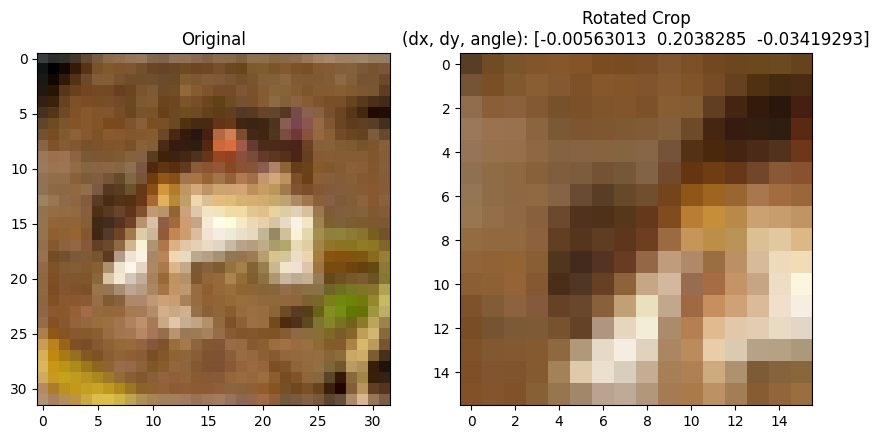

Time for 100 batches: 0.78 seconds


In [32]:
# pre-processing pipeline
def preprocess_image(image):
    # Generate random translation and rotation
    # - dx/dy in range -0.5..+0.5 (fraction of width/height)
    # - da    in range -1.0..+1.0 (radians)
    # - small stddev
    dx = tf.clip_by_value(tf.random.normal([], mean=0, stddev=0.5/4), -0.5, 0.5)
    dy = tf.clip_by_value(tf.random.normal([], mean=0, stddev=0.5/4), -0.5, 0.5)
    da = tf.clip_by_value(tf.random.normal([], mean=0, stddev=1.0/4), -1.0, 1.0)

    # Take rotated crop
    cropped = rotated_crop(image, dx, dy, da)

    # construct as input/output tuples
    transform = tf.stack([dx, dy, da])
    return (image, cropped), transform

# Create the dataset pipeline
train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(32).prefetch(tf.data.AUTOTUNE)

# Test and visualize
for (original, rotated_crop), transform in train_dataset.take(1):
    print("Original shape:", original.shape)         # [batch, 32, 32, 3]
    print("Rotated Crop shape:", rotated_crop.shape) # [batch, 16, 16, 3]
    print("Transformation shape:", transform.shape)  # [batch, 3]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(original[0])
    plt.subplot(1, 2, 2)
    plt.title(f"Rotated Crop\n(dx, dy, angle): {transform[0].numpy()}")
    plt.imshow(rotated_crop[0])
    plt.show()

# Optional: Time the pipeline
import time
start = time.time()
for _ in train_dataset.take(100):  # Process 100 batches
    pass
print(f"Time for 100 batches: {time.time() - start:.2f} seconds")

## Again


image: (32, 32, 3)
crop mid moved to: (8.0, 8.0)
T2=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 0., 8.],
       [0., 1., 8.],
       [0., 0., 1.]], dtype=float32)>
h_matrix=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 0., 8.],
       [0., 1., 8.],
       [0., 0., 1.]], dtype=float32)>
crop mid moved to: (6.650031089782715, 9.152982711791992)
T2=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 1.       ,  0.       , 10.305965 ],
       [ 0.       ,  1.       ,  5.3000617],
       [ 0.       ,  0.       ,  1.       ]], dtype=float32)>
h_matrix=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 0.98768836, -0.15643448,  9.34997   ],
       [ 0.15643448,  0.98768836,  6.847018  ],
       [ 0.        ,  0.        ,  1.        ]], dtype=float32)>
crop mid moved to: (5.136316299438477, 10.080588340759277)
T2=<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[ 1.      ,  0.      , 12.161177],
       [ 0.      ,  1.      ,  2.272632],
       [ 0

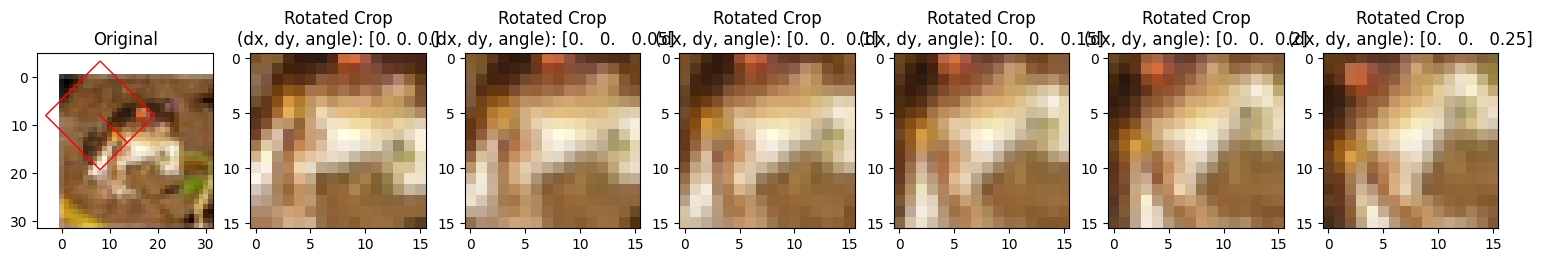

In [189]:
# image manipulation function
def draw_crop_template(image, transform):
  dx, dy, da = transform
  centre_x = image.shape[1] * (0.5 + dx)
  centre_y = image.shape[0] * (0.5 + dy)
  width = image.shape[1] // 2
  height = image.shape[0] // 2
  radians = da * np.pi

  # draw a rectangle showing the outline of where the crop was taken from
  ax = plt.gca()
  rect = patches.Rectangle((centre_x - width/2, centre_y - height/2), width, height, linewidth=1, edgecolor='r', facecolor='none')
  t = transforms.Affine2D().rotate_deg_around(centre_x, centre_y, radians * 180 / np.pi)
  rect.set_transform(t + ax.transData)
  ax.add_patch(rect)

  # draw a rotated 0-degrees line to indicate the rotation.
  line_end_x = centre_x + width / 2
  line_end_y = centre_y
  rotated_endpoint = t.transform([(line_end_x, line_end_y)])[0]
  ax.plot([centre_x, rotated_endpoint[0]], [centre_y, rotated_endpoint[1]], color='r', linewidth=1)

def show_data_sample(inputs, output):
  (image, cropped) = inputs
  transform = output
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.title("Original")
  plt.imshow(image)
  draw_crop_template(image, transform)

  plt.subplot(1, 2, 2)
  plt.title(f"Rotated Crop\n(dx, dy, angle): {transform}")
  plt.imshow(cropped)
  plt.show()

def rotated_crop(image, dx, dy, da):
    """
    Takes a 50% crop of the source image after applying a positional and angular
    offset relative to the image's centre.
    For example, (dx,dy,da) = (-0.25,0,0.5) will take a crop centred one quarter
    of the image width to the left from the source image centre and rotated
    45 degrees (50% of 180 in whichever direction the positive direction happens
    to take).
    Args:
      image: source image
      dx: float in range -0.5 .. +0.5 (fraction of width)
      dy: float in range -0.5 .. +0.5 (fraction of height)
      da: float in range -1.0 .. +1.0 (fraction of radians)
    Returns:
      cropped image
    """
    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    img_centre_x = img_width // 2
    img_centre_y = img_height // 2
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)
    crop_centre_x = crop_size // 2
    crop_centre_y = crop_size // 2

    # Compute homography matrix from translation and rotation
    cos_val = tf.cos(da * np.pi)
    sin_val = tf.sin(da * np.pi)

    # Step 1: Translate crop center by (dx * width, dy * height)
    tx1 = dx * img_width
    ty1 = dy * img_height

    tx = img_centre_x  # <-- successfully moves crop window to bottom-left quadrant
    ty = img_centre_y  # <-- aka, moves image centre to top-left pixel
    T = tf.stack([
        [1.0, 0.0, 0],
        [0.0, 1.0, 0],
        [0.0, 0.0, 1.0]
    ])

    # Step 3: Rotate source image about crop center
    R = tf.stack([
        [cos_val, -sin_val, 0],
        [sin_val, cos_val, 0],
        [0.0, 0.0, 1.0]
    ])
    R_neg = tf.stack([
        [tf.cos(-da * np.pi), -tf.sin(-da * np.pi), 0],
        [tf.sin(-da * np.pi), tf.cos(-da * np.pi), 0],
        [0.0, 0.0, 1.0]
    ])

    crop_mid = [8., 8., 1.]
    crop_mid = tf.linalg.matvec(R, crop_mid)
    print(f"crop mid moved to: ({crop_mid[0]}, {crop_mid[1]})")


    T2v = tf.linalg.matvec(R, [8., 8., 1.])
    #T2 = tf.stack([
    #    [1.0, 0.0, -T2v[0]+8],
    #    [0.0, 1.0, -T2v[1]+8],
    #    [0.0, 0.0, 1.0]
    #])

    #T2v = tf.linalg.matvec(R_neg, T2v)
    T2v = tf.linalg.matvec(R_neg, [-T2v[0]+8+8, -T2v[1]+8+8, 1.])
    T2 = tf.stack([
        [1.0, 0.0, T2v[0]],
        [0.0, 1.0, T2v[1]],
        [0.0, 0.0, 1.0]
    ])
    #T2 = tf.stack([
    #    [1.0, 0.0, 8],
    #    [0.0, 1.0, 8],
    #    [0.0, 0.0, 1.0]
    #])
    print(f"{T2=}")

    # combine transformations
    #h_matrix = T2
    #h_matrix = R
    h_matrix = tf.linalg.matmul(R, T2)
    print(f"{h_matrix=}")


    # Combine transformations: T3 * R * T2 * T1
    #h_matrix = tf.linalg.matmul(T3, tf.linalg.matmul(R, T2))
    #h_matrix = tf.linalg.matmul(T3_base, T2)  # <-- moves rotation centre to top-left pixel, then moves it to crop centre
    #h_matrix = tf.linalg.matmul(R, T2)  # <-- moves rotation centre to top-left pixel, then rotates image about top-left pixel (aka rotation centre)
    #h_matrix = tf.linalg.matmul(T3r3, tf.linalg.matmul(R, T2))
    #h_matrix = tf.linalg.matmul(R, T2)
    #h_matrix = R

    # Flatten to 8 parameters (last is 1)
    h_matrix = tf.reshape(h_matrix, [-1])[:-1]

    # Apply projective transform
    rotated_crop = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),  # Add batch dimension
        transforms=tf.expand_dims(h_matrix, 0),  # Add batch dimension
        output_shape=[crop_size, crop_size],
        interpolation='BILINEAR',
        fill_value=0.0,
        fill_mode='CONSTANT'
    )[0]  # Remove batch dimension

    return rotated_crop

image = x_train[0]
print(f"image: {image.shape}")
#transform = tf.constant(([0.0, 0.0, 0.15]))
#cropped = rotated_crop(image, dx=transform[0], dy=transform[1], da=transform[2])
#show_data_sample((image, cropped), transform)

plt.figure(figsize=(15, 5), layout='constrained')

plt.subplot(1, 7, 1)
plt.title("Original")
plt.imshow(image)
draw_crop_template(image, tf.constant(([-.25, -.25, 0.25])))
for i, da in enumerate([0.0, 0.05, 0.10, 0.15, 0.20, 0.25]):
  transform = tf.constant(([0.0, 0.0, da]))
  cropped = rotated_crop(image, dx=transform[0], dy=transform[1], da=transform[2])
  plt.subplot(1,7,i+2)
  plt.title(f"Rotated Crop\n(dx, dy, angle): {transform}")
  plt.imshow(cropped)
plt.show()

